In [1]:
from pyTEMlib.mcpclient_tems import RemoteMCPClient

In [4]:
with RemoteMCPClient("127.0.0.1", 8003) as mcp:
    init_response = mcp.initialize()
    print("Connected:", init_response["result"]["serverInfo"])

    
tools = mcp.list_tools()
    for tool in tools["result"]["tools"]:
        print(" -", tool["name"])
    result = mcp.call_tool("get_pytemlib_status", {})
    print(result)
    result = mcp.call_tool("get_available_tools", {})
    print(jasresult)


Connected: {'name': 'pyTEMlib-MCP', 'version': '4.0.3'}
 - get_pytemlib_status
 - calculate_electron_wavelength
 - list_supported_file_formats
 - open_tem_file
 - list_loaded_datasets
 - get_dataset_info
 - calculate_probe_size
 - get_element_info
 - analyze_diffraction_pattern
 - create_visualization_script
 - get_available_tools
{'jsonrpc': '2.0', 'id': 3, 'result': {'_meta': {'fastmcp': {'wrap_result': True}}, 'content': [{'text': 'pyTEMlib v0.2026.6.0 is loaded and ready. Available modules: file_tools, utilities, image_tools, eels_tools, eds_tools, crystal_tools, diffraction_tools, probe_tools, graph_tools', 'type': 'text'}], 'isError': False, 'structuredContent': {'result': 'pyTEMlib v0.2026.6.0 is loaded and ready. Available modules: file_tools, utilities, image_tools, eels_tools, eds_tools, crystal_tools, diffraction_tools, probe_tools, graph_tools'}}}
{'jsonrpc': '2.0', 'id': 4, 'result': {'_meta': {'fastmcp': {'wrap_result': True}}, 'content': [{'text': 'Available pyTEMlib MCP

In [64]:
mcp = RemoteMCPClient("127.0.0.1", 8003)
init_response = mcp.initialize()
print("Connected:", init_response["result"]["serverInfo"])
tools = mcp.list_tools()
for tool in tools["result"]["tools"]:
    print(" -", tool["name"])
mcp.call_tool("get_available_tools", {})

Connected: {'name': 'pyTEMlib-MCP', 'version': '4.0.3'}
 - get_pytemlib_status
 - calculate_electron_wavelength
 - list_supported_file_formats
 - open_tem_file
 - list_loaded_datasets
 - get_dataset_info
 - calculate_probe_size
 - get_element_info
 - analyze_diffraction_pattern
 - create_visualization_script
 - get_available_tools


Connected: {'name': 'pyTEMlib-MCP', 'version': '4.0.3'}
 - get_pytemlib_status
 - calculate_electron_wavelength
 - list_supported_file_formats
 - open_tem_file
 - list_loaded_datasets
 - get_dataset_info
 - calculate_probe_size
 - get_element_info
 - analyze_diffraction_pattern
 - create_visualization_script
 - get_available_tools


{'jsonrpc': '2.0',
 'id': 3,
 'result': {'_meta': {'fastmcp': {'wrap_result': True}},
  'content': [{'text': 'Available pyTEMlib MCP Tools:\n- get_pytemlib_status - Check if pyTEMlib is loaded\n- calculate_electron_wavelength - Calculate electron wavelength\n- list_supported_file_formats - Show supported file formats\n- open_tem_file - Open TEM data files\n- list_loaded_datasets - List currently loaded datasets\n- get_dataset_info - Get detailed dataset information\n- calculate_probe_size - Calculate electron probe size\n- get_element_info - Get element information for spectroscopy\n- analyze_diffraction_pattern - Analyze diffraction patterns\n- create_visualization_script - Generate visualization code\n- get_available_tools - List all available tools',
    'type': 'text'}],
  'isError': False,
  'structuredContent': {'result': 'Available pyTEMlib MCP Tools:\n- get_pytemlib_status - Check if pyTEMlib is loaded\n- calculate_electron_wavelength - Calculate electron wavelength\n- list_sup

In [83]:
filename = "c:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\example_data\\EDS-STO.emd"

datasets = mcp.call_tool("open_tem_file", arguments={"filename":filename})
datasets

{'jsonrpc': '2.0',
 'id': 10,
 'result': {'_meta': {'fastmcp': {'wrap_result': True}},
  'content': [{'text': 'Error opening file: \'>=\' not supported between instances of \'str\' and \'int\'\nTraceback (most recent call last):\n  File "C:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\pyTEMlib\\mcp_server.py", line 101, in open_tem_file\n    return json.dumps(datasets)  # Return all datasets as JSON for demonstration\n                      ^^^^^^^^^^^^^^^^^^^^^^\n  File "C:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\.venv\\Lib\\site-packages\\sidpy\\sid\\dataset.py", line 1805, in __getitem__\n    sliced = self.like_data(super().__getitem__(idx), checkdims=False)\n                            ~~~~~~~~~~~~~~~~~~~^^^^^\n  File "C:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\.venv\\Lib\\site-packages\\dask\\array\\core.py", line 2019, in __getitem__\n    index2 = normalize_index(index, self.shape)\n  File "

['eV']


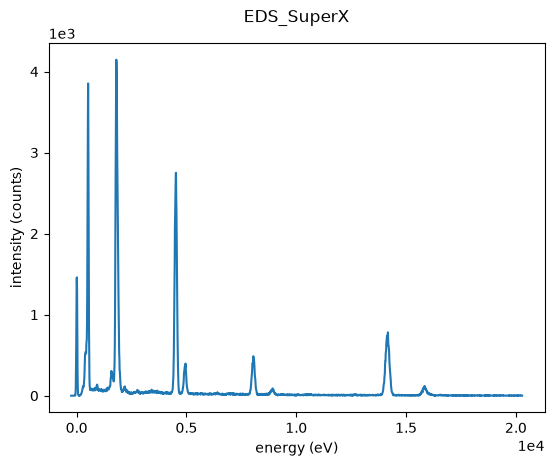

In [102]:
import pyTEMlib
filename = "c:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\example_data\\EDS-STO.emd"

datasets= pyTEMlib.file_tools.open_file(filename)

import json
dd =json_stream = io.StringIO()
meta = datasets['SuperX'].metadata
meta['data']= np.array(datasets['SuperX']).tolist()
units = []
axes = []
dimension_types = []
for key in datasets['SuperX']._axes.keys():
    axes.append(datasets['SuperX']._axes[key].values.tolist())
    units.append(datasets['SuperX']._axes[key].units)
    dimension_types.append(datasets['SuperX']._axes[key].dimension_type.name)

print(units)
meta['axes'] = {'data': axes , 'units': units, 'dimension_types': dimension_types}
meta['units'] = datasets['SuperX'].units
meta['data_type'] = datasets['SuperX'].data_type.name


json.dump(
    meta,
    json_stream,
    indent=4,
)
serialized_json = json_stream.getvalue()

v= datasets['SuperX'].plot()


In [100]:
 datasets['SuperX'].data_type.name

'SPECTRUM'

In [ ]:
units = []
axes = []
dimension_types = []
for key in datasets['SuperX']._axes.keys():
    axes.append(datasets['SuperX']._axes[key].values.tolist())
    units.append(datasets['SuperX']._axes[key].units)
    dimension_types.append(datasets['SuperX']._axes[key].dimension_type)
meta['axes'] = {'data': axes, 'units': units, 'dimension_types': dimension_types}
meta['units'] = datasets['SuperX'].units


dict_keys([0])

In [58]:
mcp.call_tool("get_element_info", arguments={"element":6})

{'jsonrpc': '2.0',
 'id': 4,
 'result': {'_meta': {'fastmcp': {'wrap_result': True}},
  'content': [{'text': 'Element: C (Z = 6)\n', 'type': 'text'}],
  'isError': False,
  'structuredContent': {'result': 'Element: C (Z = 6)\n'}}}

In [59]:
d

[{'text': '{"Channel_000":"sidpy.Dataset of type SPECTRUM with:\\n dask.array<array, shape=(2048,), dtype=float64, chunksize=(2048,), chunktype=numpy.ndarray>\\n data contains: intensity (counts)\\n and Dimensions: \\nenergy_loss:  energy-loss (eV) of size (2048,)\\n with metadata: [\'filename\', \'core_loss\', \'experiment\', \'peak_fit\', \'plot\']"}',
  'type': 'text'}]

In [44]:
import os
os.path.abspath(os.path.join("..", "example_data", "01-EELS Acquire_STO.hf5"))


'c:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\example_data\\01-EELS Acquire_STO.hf5'

In [48]:
dataset

{'jsonrpc': '2.0',
 'id': 18,
 'result': {'_meta': {'fastmcp': {'wrap_result': True}},
  'content': [{'text': 'Successfully opened c:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\example_data\\01-EELS Acquire_STO.hf5\nFound 1 datasets:\n- Channel_000: 01_EELS Acquire_STO (SPECTRUM)\n  Shape: (2048,)\n',
    'type': 'text'}],
  'isError': False,
  'structuredContent': {'result': 'Successfully opened c:\\Users\\gduscher\\OneDrive - University of Tennessee\\GitHub\\pyTEMlib\\example_data\\01-EELS Acquire_STO.hf5\nFound 1 datasets:\n- Channel_000: 01_EELS Acquire_STO (SPECTRUM)\n  Shape: (2048,)\n'}}}